In [4]:
import pandas as pd


In [5]:
general_ledger = pd.read_excel(r"C:\Users\Lenovo\Downloads\Sample GL Data 2.xlsx")
general_ledger.head(5)

,account,account_description,entered date,effective date,memo,source,transaction,debit,credit
0,15300,Hardware,2020-07-01,2020-07-01,Smart Upholstery,1523,J1,22275.0,0.00
1,21000,Accounts Payable,2020-07-01,2020-07-01,Smart Upholstery,1523,J1,0.0,23632.70
2,23150,GST Paid on Purchases,2020-07-01,2020-07-01,Smart Upholstery,1523,J1,1337.7,0.00
3,51700,Freight Expense,2020-07-01,2020-07-01,Smart Upholstery,1523,J1,20.0,0.00
4,10600,TD Bank Current,2020-07-10,2020-07-10,Wellington Hardware Inc.,115,J10,0.0,15072.48


# Data Cleaning/Preparation

In [6]:
import numpy as np
conditions = [
    general_ledger['account'].astype(str).str.startswith('1'),
    general_ledger['account'].astype(str).str.startswith('2'),
    general_ledger['account'].astype(str).str.startswith('3'),
    general_ledger['account'].astype(str).str.startswith('4'),
    general_ledger['account'].astype(str).str.startswith('5')
]

classifications = ['Assets', 'Liabilities', 'Equity', 'Revenue', 'Expenses']

conversion = [general_ledger['debit'] - general_ledger['credit'], general_ledger['credit'] - general_ledger['debit'], 
              general_ledger['credit'] - general_ledger['debit'], general_ledger['credit'] - general_ledger['debit'],
              general_ledger['credit'] - general_ledger['debit']]

general_ledger['account_type'] = np.select(conditions, classifications, default ='Other')
general_ledger['Net Change in Balance'] = np.select(conditions, conversion, default = general_ledger['debit'] - general_ledger['credit'])


In [11]:
general_ledger.head(5)


,account,account_description,entered date,effective date,memo,source,transaction,debit,credit,account_type,Net Change in Balance
0,15300,Hardware,2020-07-01,2020-07-01,Smart Upholstery,1523,J1,22275.0,0.00,Assets,22275.00
1,21000,Accounts Payable,2020-07-01,2020-07-01,Smart Upholstery,1523,J1,0.0,23632.70,Liabilities,23632.70
2,23150,GST Paid on Purchases,2020-07-01,2020-07-01,Smart Upholstery,1523,J1,1337.7,0.00,Liabilities,-1337.70
3,51700,Freight Expense,2020-07-01,2020-07-01,Smart Upholstery,1523,J1,20.0,0.00,Expenses,-20.00
4,10600,TD Bank Current,2020-07-10,2020-07-10,Wellington Hardware Inc.,115,J10,0.0,15072.48,Assets,-15072.48


In [7]:
import matplotlib.pyplot as plt
ledger_summary = general_ledger.groupby('account_type')['Net Change in Balance'].sum()

ledger_summary

account_type
Assets          267784.34
Expenses       -709167.83
Liabilities     -45176.55
Revenue        1022128.72
Name: Net Change in Balance, dtype: float64

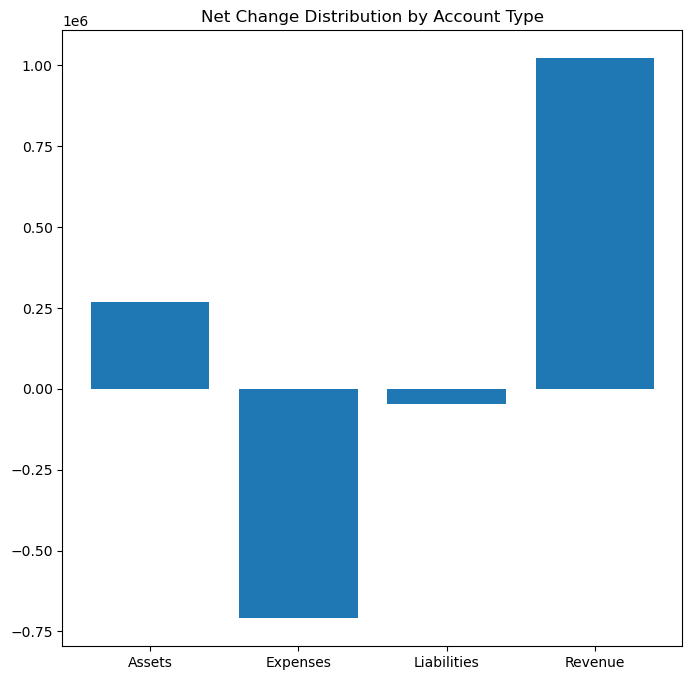

In [8]:
plt.figure(figsize=(8, 8))
plt.bar(ledger_summary.index, ledger_summary.values)
plt.title('Net Change Distribution by Account Type')
plt.show()

# **<u> Control Chart to check for outliers </u>**


General Ledger entries are not time-independent data points so a Control Chart is more applicable than the standard box-and-whiskers plot


## **<u> I-MR (Individuals-Moving Average) Chart </u>**

There are no natural subgroups of equal size for general ledger transaction records. For example, grouping 5 consecutive records into subgroups can group records made days apart or mere minutes apart instead. These differences affect the validity of any inferences made. For ease of chart creation, net changes to balance are summed up daily but since a single day can have a variable number of data points, a day cannot be treated as a subgroup with a size greater than 1. Hence, a day is treated as a subgroup of 1, necessitating the I-MR chart.   

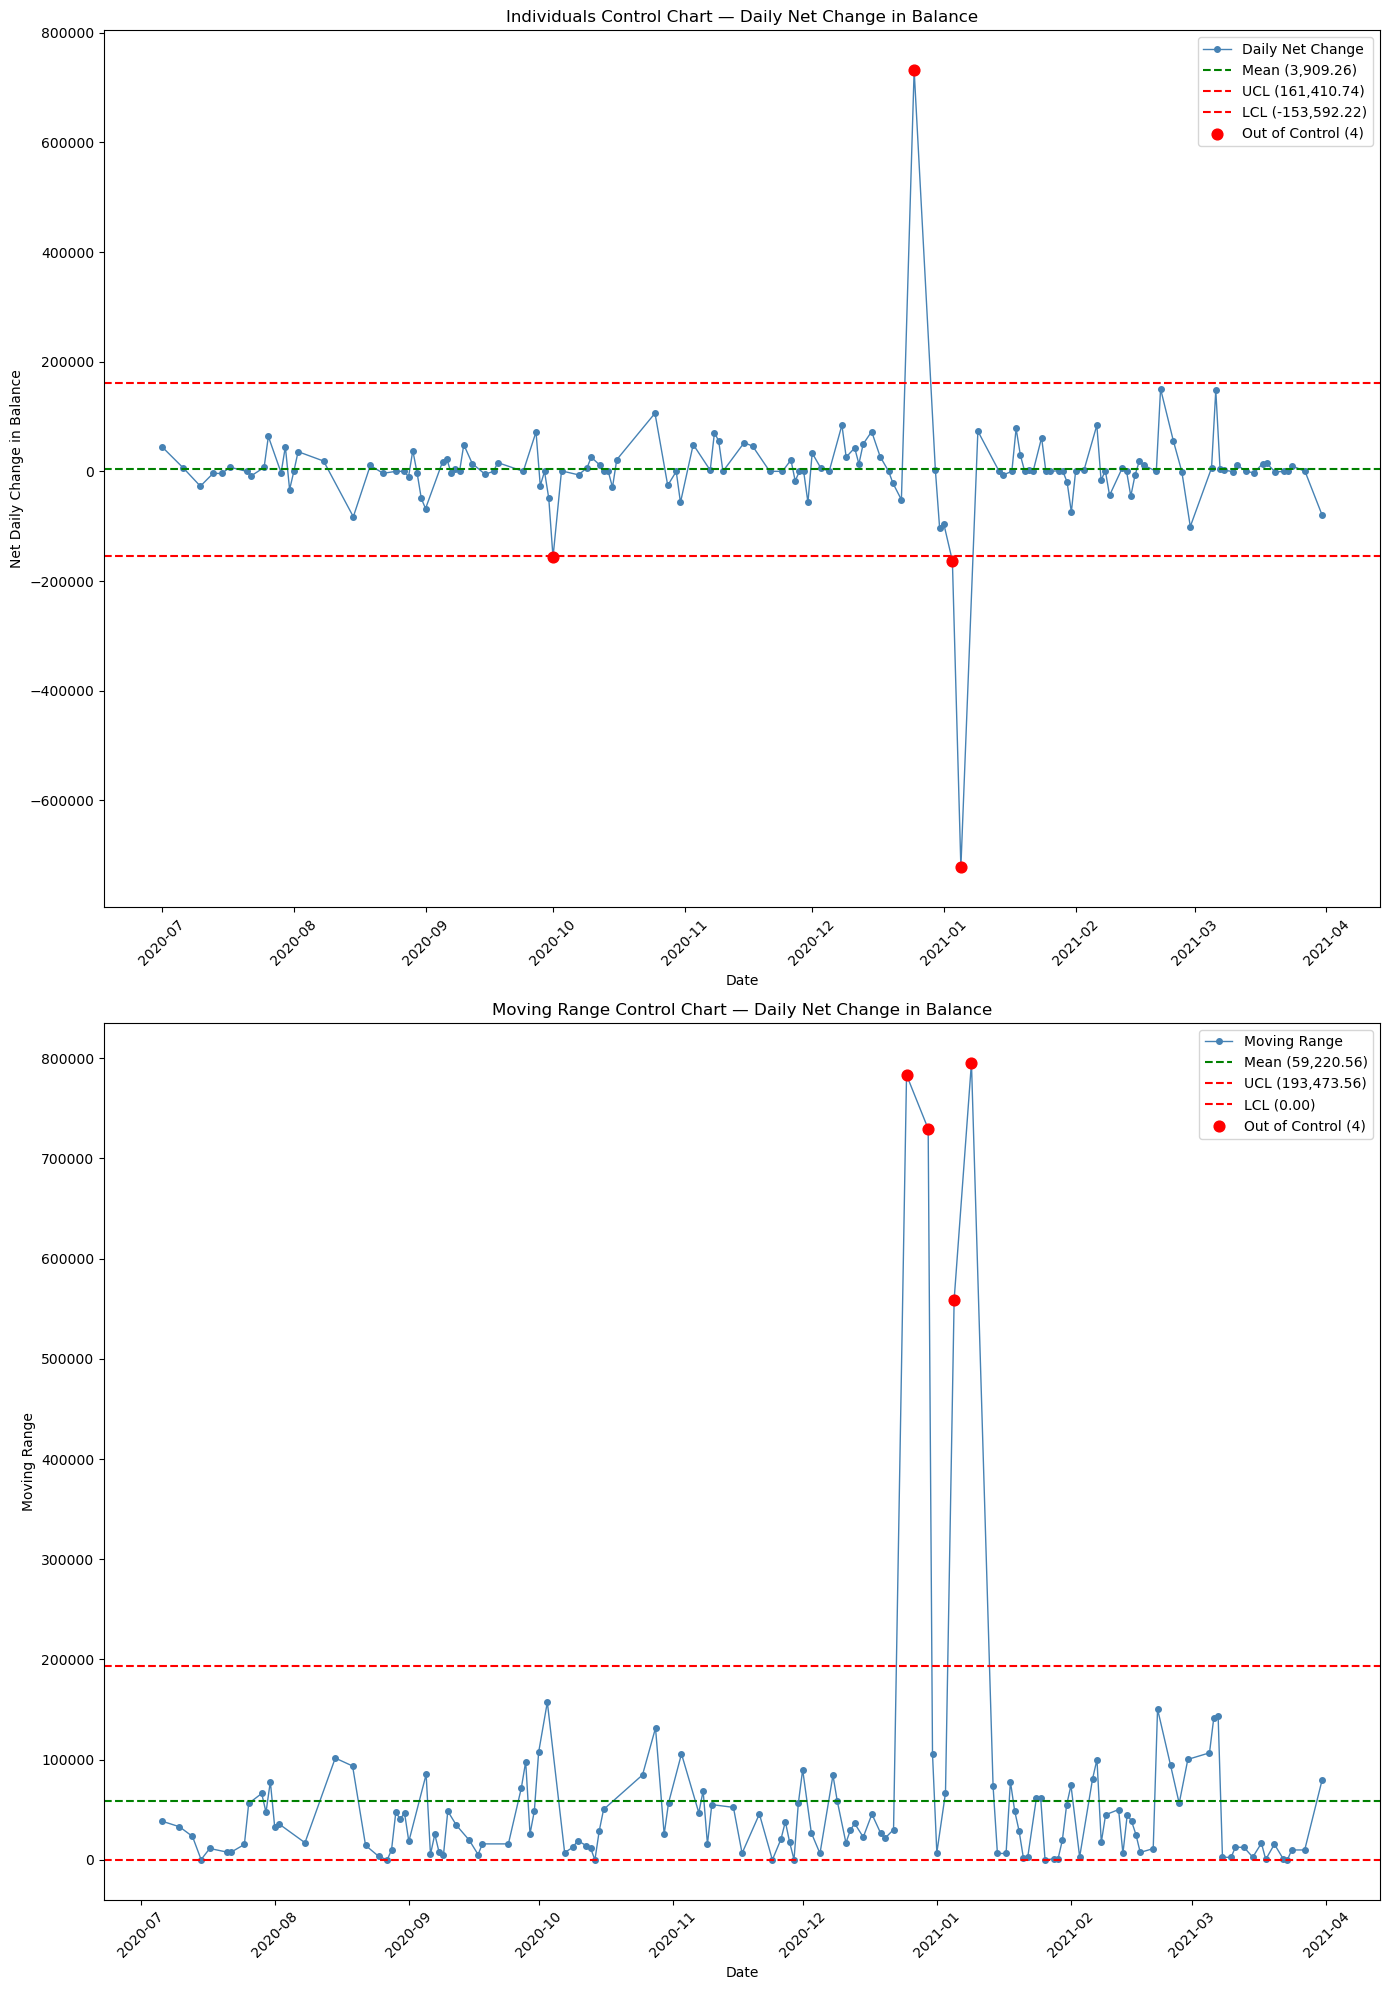

Flagged dates (Individual):
effective date
2020-10-01   -156550.58
2020-12-25    731627.12
2021-01-03   -163200.24
2021-01-05   -722268.40

Flagged dates (MR):
effective date
2020-12-25    783356.42
2020-12-30    729547.12
2021-01-05    559068.16
2021-01-09    795586.24


In [18]:
ledger_amount = general_ledger.groupby('effective date')['Net Change in Balance'].sum()
ledger_amount = ledger_amount.sort_index()

# I-MR constants (n=2) 
d2 = 1.128
E2 = 3/d2   
D3 = 0.000   # LCL factor for MR 
D4 = 3.267   # UCL factor for MR

# I-MR chart parameters
ledger_mr = ledger_amount.diff().abs()
mean = ledger_amount.mean()
std = ledger_amount.std()

mr_mean = ledger_mr.mean()
mr_std = ledger_mr.std()


ucl = mean + E2 * mr_mean
lcl = mean - E2 * mr_mean

upper_limit_mr = D4 * mr_mean
lower_limit_mr = D3 * mr_mean

fig, ax = plt.subplots(2,1,figsize=(14, 20))

# Individuals Chart
ax[0].plot(ledger_amount.index, ledger_amount.values, marker='o', linewidth=1, color='steelblue', markersize=4, label='Daily Net Change')

# Control lines
ax[0].axhline(mean, color='green',  linewidth=1.5, linestyle='--', label=f'Mean ({mean:,.2f})')
ax[0].axhline(ucl,  color='red',    linewidth=1.5, linestyle='--', label=f'UCL ({ucl:,.2f})')
ax[0].axhline(lcl,  color='red',    linewidth=1.5, linestyle='--', label=f'LCL ({lcl:,.2f})')

# Highlight out-of-control points
out_of_control = ledger_amount[(ledger_amount > ucl) | (ledger_amount < lcl)]
ax[0].scatter(out_of_control.index, out_of_control.values, color='red', zorder=5, s=60, label=f'Out of Control ({len(out_of_control)})')

ax[0].set_title('Individuals Control Chart — Daily Net Change in Balance')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Net Daily Change in Balance')
ax[0].legend()
ax[0].tick_params(axis='x', rotation=45)



# Moving Range Chart
ax[1].plot(ledger_mr.index, ledger_mr.values, marker='o', linewidth=1, color='steelblue', markersize=4, label='Moving Range')

# Control lines
ax[1].axhline(mr_mean, color='green',  linewidth=1.5, linestyle='--', label=f'Mean ({mr_mean:,.2f})')
ax[1].axhline(upper_limit_mr,  color='red',    linewidth=1.5, linestyle='--', label=f'UCL ({upper_limit_mr:,.2f})')
ax[1].axhline(lower_limit_mr,  color='red',    linewidth=1.5, linestyle='--', label=f'LCL ({lower_limit_mr:,.2f})')

# Highlight out-of-control points
out_of_control_mr = ledger_mr[(ledger_mr > upper_limit_mr) | (ledger_mr < lower_limit_mr)]
ax[1].scatter(out_of_control_mr.index, out_of_control_mr.values, color='red', zorder=5, s=60, label=f'Out of Control ({len(out_of_control_mr)})')

ax[1].set_title('Moving Range Control Chart — Daily Net Change in Balance')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Moving Range')
ax[1].legend()
ax[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()


# Print flagged dates (Individuals Chart)
if not out_of_control.empty:
    print("Flagged dates (Individual):")
    print(out_of_control.to_string() + "\n")

# Print flagged dates (Mo
if not out_of_control_mr.empty:
    print("Flagged dates (MR):")
    print(out_of_control_mr.to_string())
    



In [53]:
matched_ledger = general_ledger[general_ledger['effective date'].isin(out_of_control.index)]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(matched_ledger) 

,account,account_description,entered date,effective date,memo,source,transaction,debit,credit,account_type,Net Change in Balance
283,10600,TD Bank Current,2020-10-01,2020-10-01,Canadian Financial Funds,400,J121,0.00,10986.65,Assets,-10986.65
284,22200,RRSP Payable,2020-10-01,2020-10-01,Canadian Financial Funds,400,J121,9650.65,0.00,Liabilities,-9650.65
285,22250,RRSP - Employers Share,2020-10-01,2020-10-01,Canadian Financial Funds,400,J121,1336.00,0.00,Liabilities,-1336.00
286,10600,TD Bank Current,2020-10-01,2020-10-01,Ministare du Revenu du Quabec,401,J122,0.00,12258.12,Assets,-12258.12
287,21870,QPP Payable,2020-10-01,2020-10-01,Ministare du Revenu du Quabec,401,J122,4002.90,0.00,Liabilities,-4002.90
288,21930,Quebec Income Tax Payable,2020-10-01,2020-10-01,Ministare du Revenu du Quabec,401,J122,6009.71,0.00,Liabilities,-6009.71
289,22100,QHSF Payable,2020-10-01,2020-10-01,Ministare du Revenu du Quabec,401,J122,1831.45,0.00,Liabilities,-1831.45
290,22150,QPIP Payable,2020-10-01,2020-10-01,Ministare du Revenu du Quabec,401,J122,414.06,0.00,Liabilities,-414.06
291,10600,TD Bank Current,2020-10-01,2020-10-01,Receiver General,402,J123,0.00,53235.52,Assets,-53235.52
292,21800,EI Payable,2020-10-01,2020-10-01,Receiver General,402,J123,8732.57,0.00,Liabilities,-8732.57


In [54]:
matched_ledger_mr = general_ledger[general_ledger['effective date'].isin(out_of_control_mr.index)]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(matched_ledger_mr) 

,account,account_description,entered date,effective date,memo,source,transaction,debit,credit,account_type,Net Change in Balance
1243,12000,Accounts Receivable,2020-12-25,2020-12-25,Bayswater School Board,27827,J235,5642.66,0.00,Assets,5642.66
1244,15200,Drywall,2020-12-25,2020-12-25,Bayswater School Board,27827,J235,0.00,145.31,Assets,-145.31
1245,15300,Hardware,2020-12-25,2020-12-25,Bayswater School Board,27827,J235,0.00,425.99,Assets,-425.99
1246,15400,Lumber,2020-12-25,2020-12-25,Bayswater School Board,27827,J235,0.00,392.00,Assets,-392.00
1247,23000,PST Payable,2020-12-25,2020-12-25,Bayswater School Board,27827,J235,0.00,349.55,Liabilities,349.55
1248,23100,GST Charged on Sales,2020-12-25,2020-12-25,Bayswater School Board,27827,J235,0.00,299.61,Liabilities,299.61
1249,42100,Sales: Home Furniture,2020-12-25,2020-12-25,Bayswater School Board,27827,J235,0.00,283.50,Revenue,283.50
1250,42200,Sales: Office Furniture,2020-12-25,2020-12-25,Bayswater School Board,27827,J235,0.00,2835.00,Revenue,2835.00
1251,42300,Sale: Lighting,2020-12-25,2020-12-25,Bayswater School Board,27827,J235,0.00,1800.00,Revenue,1800.00
1252,44100,Freight Revenue,2020-12-25,2020-12-25,Bayswater School Board,27827,J235,0.00,75.00,Revenue,75.00


# <u> Analysis </u>

Looking through the transaction records on the dates highlighted by the I-MR chart, the most suspicious aspect is how the reversals on customer sales are handled. For customer71 and customer72, the same accounts used to account for sales made to them are used to reverse sales when they are canceled (e.g. transaction 3838 and 3843). However, for customer73 and customer74, the account "Other Income" is used instead to reverse cancelled sales (e.g. transaction 3864). This discrepency is unusual and is grounds for follow up checks with the Accounting Department.


# **<u> Benford's law to check for outliers </u>**

Another useful method to highlight discrepancies is Benford's law, which is best for detecting fraud in transaction entries


In [35]:
observed_freq.sum()

np.float64(1.0)

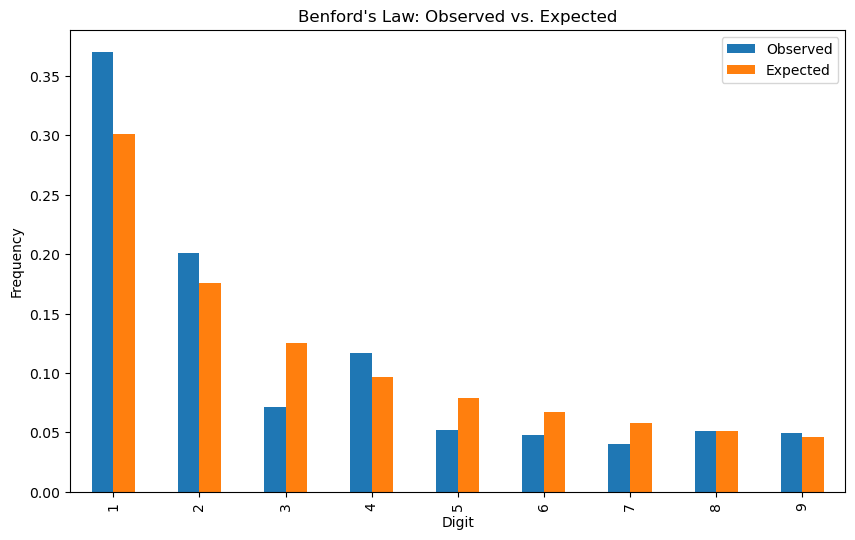

Chi-Square Statistic: 0.0669
P-value: 1.0000


In [36]:


# Extract leading digit
abs_values = general_ledger['Net Change in Balance'].abs()

# Drop zeros (no leading digit exists for 0)
abs_values = abs_values[abs_values != 0]

first_digits = np.floor(abs_values / 10 ** np.floor(np.log10(abs_values))).astype(int) # Handles decimal values e.g. 0.04 becomes 4

# Calculate Benford's Law Expected Frequencies
digits = np.arange(1, 10)
expected_freq = np.log10(1 + 1 / digits)

# Calculate Observed Frequencies 
observed_freq = first_digits.value_counts(normalize=True).reindex(digits, fill_value=0).sort_index() #Ensures only digit 0 is not considered


benford_df = pd.DataFrame({
    'Digit': digits,
    'Observed': observed_freq.values,
    'Expected': expected_freq
})


# Visualisation
benford_df.set_index('Digit').plot(kind='bar', figsize=(10, 6))
plt.title("Benford's Law: Observed vs. Expected")
plt.ylabel('Frequency')
plt.show()


# Chi-Square Goodness-of-Fit test to check if the observed frequency fits the expected frequency

from scipy.stats import chisquare

chi2_stat, p_value = chisquare(observed_freq, expected_freq)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")



# <u> Analysis </u>

Since p-value is greater than 0.05, there is no statistical evidence that the distribution of observed frequencies differs from the distribution of expected frequencies. Hence, Benford's Law doesn't show any possible fraud in this General Ledger dataset 